# GSB 5544 — Topic 6-1: Writing functions

In [1]:
!pip install palmerpenguins

In [2]:
import numpy as np
import pandas as pd
from sys import exit
from palmerpenguins import load_penguins
from plotnine import ggplot, aes, geom_point, geom_bar

0\. Complete the [**check-in** from Section 6.3.2](https://ds-ml-with-python.github.io/Course-Textbook/05-function_writing.html#nested-environments-and-scope): Write a custom function that does the following:

Limit the penguins dataset to a user-chosen species and/or island.
Makes a scatterplot of the penguin bill length and depth.
Try writing a version of this function using dynamic lookup, and a version where everything the function needs is passed in directly

In [3]:
penguins = load_penguins()

def plot_bills_dynamic(species=None, island=None):
    penguin_subset = penguins.copy()

    if species is not None:
        penguin_subset = penguin_subset[penguin_subset["species"] == species]

    if island is not None:
        penguin_subset = penguin_subset[penguin_subset["island"] == island]

    penguin_subset = penguin_subset.dropna(
        subset=["bill_length_mm", "bill_depth_mm"]
    )

    plot = (
        ggplot(
            penguin_subset,
            aes(x="bill_length_mm", y="bill_depth_mm")
        )
        + geom_point()
    )

    return plot

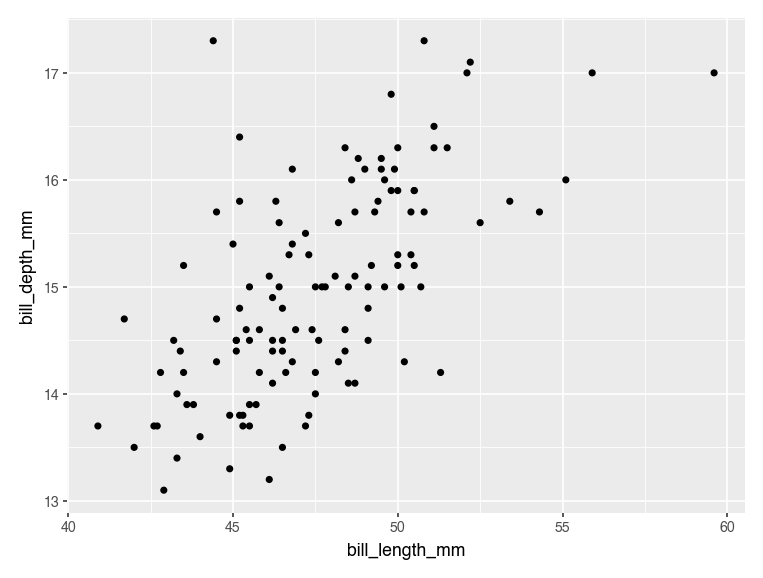

In [4]:
plot_bills_dynamic(species="Gentoo")

In [5]:
def penguin_scatter(data, species=None, island=None):
    
    penguin_subset = data.copy()

    if species is not None:
        penguin_subset = penguin_subset[
            penguin_subset["species"] == species
        ]

    if island is not None:
        penguin_subset = penguin_subset[
            penguin_subset["island"] == island
        ]

    penguin_subset = penguin_subset.dropna()

    plot = (
        ggplot(
            penguin_subset,
            aes(x="bill_length_mm", y="bill_depth_mm")
        )
        + geom_point()
    )
    return plot

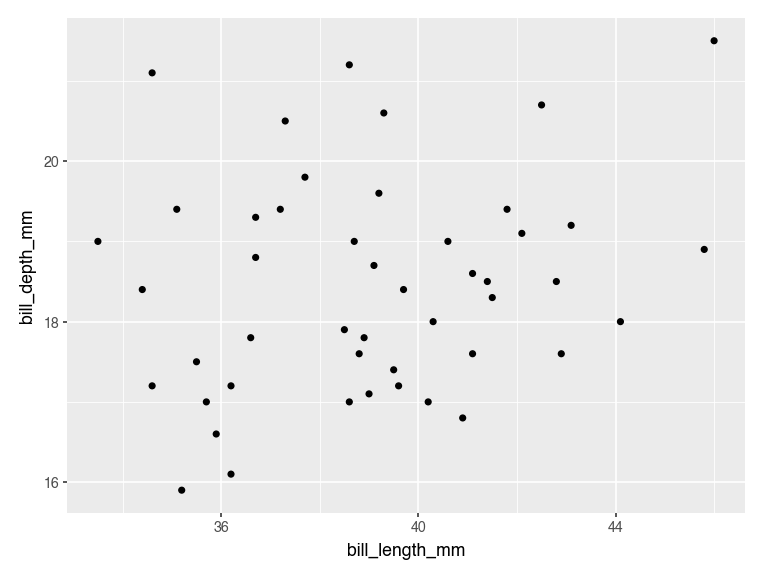

In [6]:
penguin_scatter(penguins, species="Adelie", island="Torgersen")

1. Fill in the necessary code to write a function called `times_seven()`. The function should take a single argument (`x`) and multiply the input by 7.
  + This function should check that the argument is numeric.
  + This function should also excitedly announce (print) *“I love sevens!”* if the argument to the function is a 7.

In [7]:
def times_seven(x):

    if not isinstance(x, (int, float)):
        exit("x must be numeric.")

    if x == 7:
        print("I love sevens!")

    return x * 7

In [8]:
times_seven(7)

I love sevens!


49

2. Write and run some *unit tests* for your `times_seven` function.  What happens if the input to the function is `[1, 3, 5, 7]`?


When the input is [1, 3, 5, 7], the function stops and returns the message x must be numeric. This is because the input is a list, not a single numeric value.

In [9]:
times_seven(2)

14

In [10]:
times_seven(7)

I love sevens!


49

In [11]:
times_seven("hello")

SystemExit: x must be numeric.

In [ ]:
times_seven([1, 3, 5, 7])

SystemExit: x must be numeric.

3. Consider the following function:

In [13]:
def add_or_subtract(first_num, second_num = 2, type = "add"):

  if (type == "add"):
    res = first_num + second_num
  elif (type == "subtract"):
    res = first_num - second_num
  else:
    exit("Please choose `add` or `subtract` as the type.")

    return res

**Without running the code**, predict if the following will produce:

a. 1

b. -1 
#add_or_subtract(5, 6, type="subtract") 

c. 30

d. An error defined by the function `add_or_subtract()`. 
#add_or_subtract(5, 6, type="multiply") 

e. An error defined in a different function, which is called inside the `add_or_subtract()` function.    
#add_or_subtract("orange") 

In [ ]:
add_or_subtract(5, 6, type = "subtract")

add_or_subtract("orange")

add_or_subtract(5, 6, type = "multiply")

4. Consider the following code:

In [14]:
first_num  = 5
second_num = 3

result = 8

result = add_or_subtract(first_num, second_num = 4)

result_2 = add_or_subtract(first_num)


In your Global Environment, what is the value of...

a. `first_num` = 5

b. `second_num` = 3

c. `result` = 9

d. `result_2`  = 7